# FD-CMKD from scratch

The distillation runs reported in the thesis are **warm-started**: they load the
converged baseline checkpoint and fine-tune it with the transfer loss. That design
answers *does the teacher improve an already-trained student?* -- and, under a
matched control, the answer was no.

It leaves a different question open: *does the teacher help when present from the
start?* A teacher seen from random initialization can shape the representation as it
forms, rather than nudge a model already settled in a minimum. This notebook trains
the full FD-CMKD student **from scratch** so that question can be answered too.

**What makes the comparison fair.** Every training hyperparameter in
`from_scratch_fd_cmkd.yaml` is copied verbatim from the baseline `sign.yaml`, and the
config carries no `load_model`. The only difference between this run and the CTC-only
baseline (39.54 dev / 41.53 test) is the distillation loss. To read a result as
evidence rather than anecdote, give this run the same learning-rate search the
baseline had (the Optuna cell), and fix a decision margin before you look.

**The warmup ramp.** From scratch, the projection and the shared classifiers start
random, so their gradient is noise until CTC pulls the encoder out of blank collapse
(the first couple of epochs). `distill_warmup_steps` ramps the distillation weight in
linearly over that window; without it, a from-scratch run can be destabilised early
and you would not know whether the teacher or the initialization was at fault.

In [1]:
# Run from code/distillation/ no matter where the kernel was launched.
import os
if not os.path.exists('fd_cmkd.py'):
    _cwd = os.getcwd()
    for _k in range(0, 6):
        _base = os.path.abspath(os.path.join(_cwd, *(['..'] * _k)))
        _cand = os.path.join(_base, 'code', 'distillation')
        if os.path.exists(os.path.join(_cand, 'fd_cmkd.py')):
            os.chdir(_cand); break
        if os.path.exists(os.path.join(_base, 'fd_cmkd.py')):
            os.chdir(_base); break
print('working dir:', os.getcwd())

# Where this run writes -- same convention as the other notebooks.
# Output goes to runs/<RUN_NAME>/; dataset/checkpoints/ is never touched.
import os

RUN_NAME  = 'forward_scratch_control'
OVERWRITE = False        # False: version to _002, _003, ... instead of deleting
DO_TRAIN  = False        # True: train from scratch (up to 1000 epochs, early-stopped)

RUN_DIR = os.path.join('../../runs', RUN_NAME)
if os.path.exists(RUN_DIR) and not OVERWRITE:
    _n = 2
    while os.path.exists('%s_%03d' % (RUN_DIR, _n)):
        _n += 1
    RUN_DIR = '%s_%03d' % (RUN_DIR, _n)
print('this run writes to:', os.path.normpath(os.path.abspath(RUN_DIR)))

# This notebook evaluates only its own run.
EVAL_CKPT = 'mine'

working dir: /home/ebufi/Sign-Language-Recognition/code/distillation
this run writes to: /home/ebufi/Sign-Language-Recognition/runs/forward_scratch_control_004


In [2]:
import sys, yaml

SIGNFORMER_DIR = os.path.abspath('../signformer')   # for `import main.*`
NB_DIR = os.path.abspath('.')                        # for `import fd_cmkd*`
for _p in (SIGNFORMER_DIR, NB_DIR):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import main.training as mt
from fd_cmkd_trainer import train_fd_cmkd
from fd_cmkd import load_teacher_feats
print('imports OK')

I0000 00:00:1783953850.191906 2142952 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


imports OK


In [3]:
# Sanity checks: data and teacher features present, config genuinely from-scratch.
BASE_CFG = 'from_scratch_fd_cmkd.yaml'
assert os.path.exists(BASE_CFG), 'missing config: ' + BASE_CFG

cfg = yaml.safe_load(open(BASE_CFG))
dc = cfg['training']['distillation']

i3d = os.path.join(cfg['data']['data_path'], cfg['data']['train'])
assert os.path.exists(i3d), 'missing I3D features: ' + i3d

tfp = os.path.join(dc['teacher_feats_dir'], 'train.pkl')
assert os.path.exists(tfp), 'missing teacher features: ' + tfp
_t = load_teacher_feats(tfp)

assert 'load_model' not in cfg['training'], 'a from-scratch run must not warm-start'
print('i3d train features : OK')
print('teacher features   : %d videos, dim %d' % (len(_t), next(iter(_t.values())).shape[1]))
print('warm-start         : none (trains from random init)')
print('distill warmup     : %d steps' % dc['distill_warmup_steps'])

i3d train features : OK
teacher features   : 7096 videos, dim 512
warm-start         : none (trains from random init)
distill warmup     : 500 steps


In [4]:
# === MATCHED CONTROL for Module 2, from scratch (future works) ===
cfg['training']['distillation']['enabled'] = False
DO_TRAIN = True
print('CONTROL ARM (Module 2, scratch): teacher OFF')


CONTROL ARM (Module 2, scratch): teacher OFF


In [5]:
# Point the config at RUN_DIR, honour OVERWRITE, write the resolved config there.
# The committed from_scratch_fd_cmkd.yaml is never modified.
# RUN_DIR is a container. The trainer writes into RUN_DIR/final, which it must
# be free to create fresh: make_model_dir refuses a directory that already
# exists. Writing the config into RUN_DIR (not into MODEL_DIR) keeps them apart.
MODEL_DIR = os.path.join(RUN_DIR, 'final')
cfg['training']['model_dir'] = MODEL_DIR
cfg['training']['overwrite'] = OVERWRITE

os.makedirs(RUN_DIR, exist_ok=True)
ACTIVE_CFG = os.path.join(RUN_DIR, 'from_scratch_fd_cmkd.yaml')
with open(ACTIVE_CFG, 'w') as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

tr = cfg['training']
print('active config ->', ACTIVE_CFG)
print('lr=%.3e  wd=%.3e  batch=%d  patience=%d' % (tr['learning_rate'], tr['weight_decay'], tr['batch_size'], tr['early_stopping_patience']))
print('lambda_feat=%.3f  lambda_align=%.3f  w_high=%.3f  warmup=%d' % (dc['lambda_feat'], dc['lambda_align'], dc['high_w'], dc['distill_warmup_steps']))

active config -> ../../runs/forward_scratch_control_004/from_scratch_fd_cmkd.yaml
lr=3.123e-04  wd=4.984e-03  batch=32  patience=10
lambda_feat=0.161  lambda_align=0.150  w_high=0.292  warmup=500


## Optional: matched learning-rate search

The baseline was selected over a small Optuna search. For the comparison to be fair,
the from-scratch distilled arm deserves a search of the **same budget** over the
**same learning-rate range**. Turn it on to run it; each trial writes to a temporary
directory under `RUN_DIR`, and the best learning rate is kept.

Leave it off (`USE_OPTUNA = False`) to train a single run at the baseline learning
rate -- a quick check that the pipeline works, but not, on its own, evidence.

In [6]:
import copy, shutil, gc

USE_OPTUNA    = False   # True re-runs the matched search (hours)
OPTUNA_TRIALS = 6       # match the baseline budget
LR_RANGE      = (1.5e-4, 6e-4)   # a neighbourhood of the baseline 3.12e-4

if USE_OPTUNA and DO_TRAIN:
    import torch
    try:
        import optuna
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
        import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    _log = []
    def _objective(trial):
        lr = trial.suggest_float('learning_rate', LR_RANGE[0], LR_RANGE[1], log=True)
        ct = copy.deepcopy(cfg)
        ct['training']['learning_rate'] = float(lr)
        td = os.path.join(RUN_DIR, 'optuna', 'trial_%02d' % trial.number)
        ct['training']['model_dir'] = td
        ct['training']['overwrite'] = True
        # config beside the trial dir, not inside: make_model_dir wipes the
        # dir (overwrite=True) and would delete a config written into it.
        os.makedirs(os.path.dirname(td), exist_ok=True)
        cf = td + '.yaml'
        with open(cf, 'w') as f:
            yaml.safe_dump(ct, f, sort_keys=False)
        train_fd_cmkd(cf)
        wers = []
        vf = os.path.join(ct['training']['model_dir'], 'validations.txt')
        if os.path.exists(vf):
            for line in open(vf):
                toks = line.replace(':', ' ').split()
                if 'WER' in toks:
                    try:
                        wers.append(float(toks[toks.index('WER') + 1]))
                    except (ValueError, IndexError):
                        pass
        best = min(wers) if wers else 100.0
        _log.append((trial.number, lr, best))
        print('  trial %d: lr=%.3e -> dev WER %.2f' % (trial.number, lr, best))
        shutil.rmtree(td, ignore_errors=True)
        if os.path.exists(cf):
            os.remove(cf)
        gc.collect(); torch.cuda.empty_cache()
        return best

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(_objective, n_trials=OPTUNA_TRIALS)
    print('best lr:', study.best_params, '-> dev WER', round(study.best_value, 2))
    cfg['training']['learning_rate'] = float(study.best_params['learning_rate'])
    with open(ACTIVE_CFG, 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    print('ACTIVE_CFG updated with the searched learning rate.')
else:
    print('Optuna search disabled (or DO_TRAIN=False) -- using the config lr.')

Optuna search disabled (or DO_TRAIN=False) -- using the config lr.


In [7]:
import torch
torch.backends.cudnn.enabled = False
# Train from scratch. This is the long cell.
if DO_TRAIN:
    train_fd_cmkd(ACTIVE_CFG)
else:
    print('DO_TRAIN = False -> skipping training. Set it True to run from scratch.')

2026-07-13 16:44:28,835 Hello! This is SL-CAT.
2026-07-13 16:44:28,837 Total params: 3,757,577
2026-07-13 16:44:28,838 Trainable parameters: ['encoder.layer_norm.bias', 'encoder.layer_norm.weight', 'encoder.layers.0.FF2.module.layer_norm.bias', 'encoder.layers.0.FF2.module.layer_norm.weight', 'encoder.layers.0.FF2.module.pwff_layer.0.bias', 'encoder.layers.0.FF2.module.pwff_layer.0.weight', 'encoder.layers.0.FF2.module.pwff_layer.3.bias', 'encoder.layers.0.FF2.module.pwff_layer.3.weight', 'encoder.layers.0.att.module.attention.attn_net.bias', 'encoder.layers.0.att.module.attention.attn_net.weight', 'encoder.layers.0.att.module.attention.k_proj.bias', 'encoder.layers.0.att.module.attention.k_proj.weight', 'encoder.layers.0.att.module.attention.offset_net.0.bias', 'encoder.layers.0.att.module.attention.offset_net.0.weight', 'encoder.layers.0.att.module.attention.offset_net.2.bias', 'encoder.layers.0.att.module.attention.offset_net.2.weight', 'encoder.layers.0.att.module.attention.out_pro

COPE:  False
[builders] SophiaG unavailable, falling back to Adam


/home/ebufi/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
2026-07-13 16:44:29,541 FD-CMKD disabled — plain finetuning.
2026-07-13 16:44:29,542 Data set sizes: 
	train 7094,
	valid 519,
	test 642
2026-07-13 16:44:29,542 First training example:
	[GLS] JETZT WETTER MORGEN DONNERSTAG ZWOELF FEBRUAR
	[TXT] und nun die wettervorhersage für morgen donnerstag den zwölften august
2026-07-13 16:44:29,543 First 10 words (gls): (0) <si> (1) <unk> (2) <pad> (3) REGEN (4) REGION (5) IX (6) KOMMEN (7) MORGEN (8) NORD (9) SONNE
2026-07-13 16:44:29,544 First 10 words (txt): (0) <unk> (1) <pad> (2) <s> (3) </s> (4) und (5) im (6) es (7) der (8) am (9) in
2026-07-13 16:44:29,544 Number of unique glosses (types): 1087
2026-07-13 16:44:29,545 Number of unique words (types): 2888
2026-07-13 16:44:29,547 EPOCH 1
2026-07-13 16:44:35,452 [Epoch: 001 Step: 00000100] Batch 

COPE:  False


2026-07-13 17:38:19,007 finished in 13.3927s 
2026-07-13 17:38:19,008 ************************************************************
2026-07-13 17:38:19,008 [DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 1
	WER 39.83	(DEL: 11.71,	INS: 4.80,	SUB: 23.32)
2026-07-13 17:38:19,009 ************************************************************
2026-07-13 17:38:19,009 ------------------------------------------------------------
2026-07-13 17:38:19,009 [DEV] partition [RECOGNITION] experiment [BW]: 2
2026-07-13 17:38:41,786 finished in 22.7768s 
2026-07-13 17:38:41,787 ------------------------------------------------------------
2026-07-13 17:38:41,787 [DEV] partition [RECOGNITION] experiment [BW]: 3
2026-07-13 17:39:14,236 finished in 32.4490s 
2026-07-13 17:39:14,237 ************************************************************
2026-07-13 17:39:14,237 [DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 3
	WER 39.73	(DEL: 11.42,	INS: 4.86,	SUB: 23.45)
202

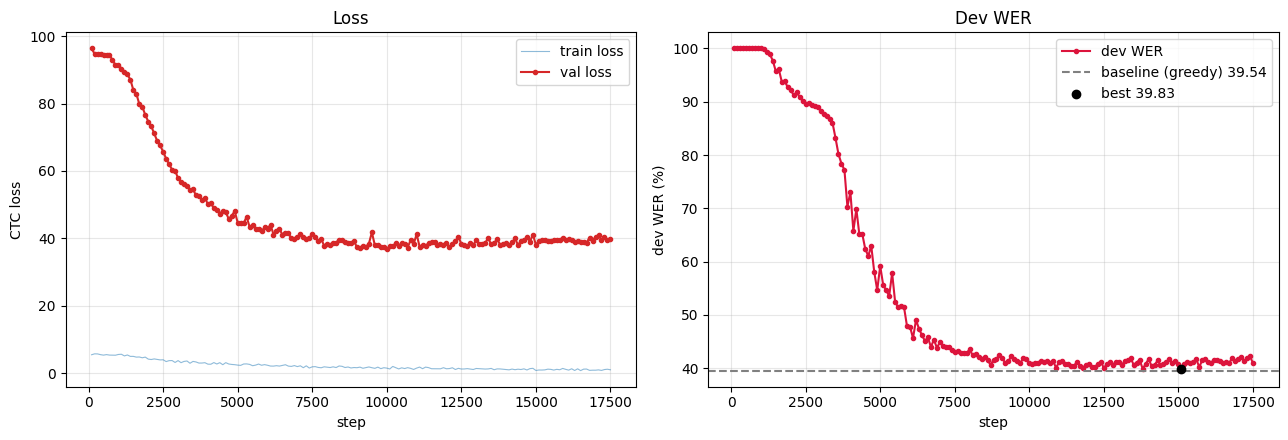

best dev WER : 39.83 at step 15100
last val loss: 39.830
last train loss: 1.074


In [8]:
# Curves: train loss and validation loss (left), dev WER (right).
import re
import matplotlib.pyplot as plt
from main.helpers import parse_validations

MDIR = os.path.join(RUN_DIR, 'final')
val = parse_validations(MDIR)   # steps, recognition_loss (dev), wer, lr

# Train loss is logged per step in train.log, not in validations.txt.
tr_steps, tr_loss = [], []
logp = os.path.join(MDIR, 'train.log')
if os.path.exists(logp):
    for line in open(logp, encoding='utf-8', errors='ignore'):
        ms = re.search(r'Step:\s*(\d+)', line)
        ml = re.search(r'Batch Recognition Loss:\s*([\d.]+)', line)
        if ms and ml:
            tr_steps.append(int(ms.group(1)))
            tr_loss.append(float(ml.group(1)))

if not val['steps'] and not tr_steps:
    print('no logs yet in', MDIR, '(train first, DO_TRAIN = True)')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    if tr_steps:
        ax1.plot(tr_steps, tr_loss, lw=0.8, alpha=0.5, color='tab:blue', label='train loss')
    if val['steps']:
        ax1.plot(val['steps'], val['recognition_loss'], marker='o', ms=3,
                 color='tab:red', label='val loss')
    ax1.set_xlabel('step'); ax1.set_ylabel('CTC loss'); ax1.set_title('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    if val['steps']:
        ax2.plot(val['steps'], val['wer'], marker='o', ms=3, color='crimson', label='dev WER')
        ax2.axhline(39.54, ls='--', c='gray', label='baseline (greedy) 39.54')
        good = [(s, w) for s, w in zip(val['steps'], val['wer']) if w == w]
        if good:
            bs, bw = min(good, key=lambda t: t[1])
            ax2.scatter([bs], [bw], color='black', zorder=5, label='best %.2f' % bw)
    ax2.set_xlabel('step'); ax2.set_ylabel('dev WER (%)'); ax2.set_title('Dev WER')
    ax2.legend(); ax2.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(os.path.join(MDIR, 'training_curves.png'), dpi=120)
    plt.show()

    if val['steps']:
        good = [(s, w) for s, w in zip(val['steps'], val['wer']) if w == w]
        if good:
            bs, bw = min(good, key=lambda t: t[1])
            print('best dev WER : %.2f at step %d' % (bw, bs))
        vl = [x for x in val['recognition_loss'] if x == x]
        if vl:
            print('last val loss: %.3f' % vl[-1])
    if tr_loss:
        print('last train loss: %.3f' % tr_loss[-1])


In [9]:
# Evaluate the best-on-dev checkpoint and lay the numbers next to the baseline.
best_ckpt = os.path.join(RUN_DIR, 'final', 'best.ckpt')
if not os.path.exists(best_ckpt):
    print('no best.ckpt yet -- train first (DO_TRAIN = True).')
else:
    mt.test(ACTIVE_CFG, ckpt=best_ckpt, output_path=os.path.join(RUN_DIR, 'final', 'test_output'))
    print()
    print('Baseline, from scratch, CTC only (sign.yaml):')
    print('   dev  39.54 greedy / 39.35 beam-4      test  41.53')
    print('This run, from scratch, CTC + FD-CMKD:')
    print('   see the [DEV] and [TEST] WER printed above')
    print()
    print('Reading the result:')
    print(' - below baseline beyond the margin: warm-start was hiding a real transfer.')
    print(' - within the margin: the last alternative explanation is ruled out.')
    print(' - above baseline: a weak teacher shaping the representation transfers its confusion.')

2026-07-13 17:49:06,783 - ------------------------------------------------------------
2026-07-13 17:49:06,784 - [DEV] partition [RECOGNITION] experiment [BW]: 1


COPE:  False


2026-07-13 17:49:20,315 - finished in 13.5317s 
2026-07-13 17:49:20,316 - ************************************************************
2026-07-13 17:49:20,316 - [DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 1
	WER 39.83	(DEL: 11.71,	INS: 4.80,	SUB: 23.32)
2026-07-13 17:49:20,317 - ************************************************************
2026-07-13 17:49:20,317 - ------------------------------------------------------------
2026-07-13 17:49:20,317 - [DEV] partition [RECOGNITION] experiment [BW]: 2
2026-07-13 17:49:43,267 - finished in 22.9499s 
2026-07-13 17:49:43,268 - ------------------------------------------------------------
2026-07-13 17:49:43,268 - [DEV] partition [RECOGNITION] experiment [BW]: 3
2026-07-13 17:50:15,846 - finished in 32.5781s 
2026-07-13 17:50:15,847 - ************************************************************
2026-07-13 17:50:15,847 - [DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 3
	WER 39.73	(DEL: 11.42,	IN


Baseline, from scratch, CTC only (sign.yaml):
   dev  39.54 greedy / 39.35 beam-4      test  41.53
This run, from scratch, CTC + FD-CMKD:
   see the [DEV] and [TEST] WER printed above

Reading the result:
 - below baseline beyond the margin: warm-start was hiding a real transfer.
 - within the margin: the last alternative explanation is ruled out.
 - above baseline: a weak teacher shaping the representation transfers its confusion.
